# Static and Transient XAS Modeling of [Fe(terpy)$_2$]$^{2+}$

Fits a step-edge + Gaussians model to the static ground- and excited-state Fe K-edge XANES spectra, then builds a pump-probe transient XAS map from an IRF-convolved excited-state population.

Physical background: `docs/physics/01_xas_xanes.md` (the static model) and `docs/physics/03_ultrafast_pump_probe_kinetics.md` (the transient kinetics).

This merges and supersedes the earlier `Model_XAS_for_VLAB.ipynb` and `Modified_Model_XAS_for_VLAB.ipynb` (kept in the `archive/` folder of the older `Python_Scripts_VLab` checkout, not carried over here), adopting the physically-correct erf edge-broadening from the latter.

In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Run from the repository root and import `vlab_xray` from this repository's
# own `src/`, so that `data/` and `figures/` resolve identically no matter
# where Jupyter was started and an editable install of another copy of the
# package cannot shadow these sources.
ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents)
            if (p / "src" / "vlab_xray").is_dir())
os.chdir(ROOT)
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

from vlab_xray import io as vio
from vlab_xray.lineshapes import erf_step, gaussian
from vlab_xray.xas_model import xas_model, fit_static_xas
from vlab_xray.kinetics import (
    excited_state_population,
    product_state_population,
    build_transient_xas_map,
)

## Load and Prepare Experimental Data

In [2]:
# Laser-on/laser-off XAS scan, with an extrapolated 100%-excited-state
# column ("ES") added by the loader (see docs/physics/01_xas_xanes.md).
data = vio.load_pump_probe_xas()
data

,Energy,ON,OFF,Diff,ES
0,7.600000,0.139081,0.139012,0.000069,0.139103
1,7.597751,0.138977,0.138990,-0.000013,0.138973
2,7.595507,0.139337,0.139005,0.000331,0.139441
3,7.593268,0.139177,0.138957,0.000221,0.139247
4,7.591036,0.139309,0.139121,0.000188,0.139368
...,...,...,...,...,...
526,7.083999,0.005814,0.005739,0.000074,0.005837
527,7.082999,0.005764,0.005704,0.000061,0.005784
528,7.081998,0.005735,0.005694,0.000040,0.005747
529,7.080998,0.005675,0.005670,0.000005,0.005677


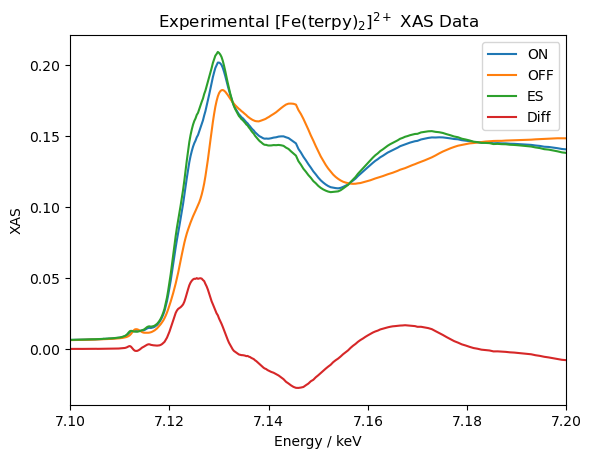

In [3]:
plt.plot(data['Energy'], data['ON'])
plt.plot(data['Energy'], data['OFF'])
plt.plot(data['Energy'], data['ES'])
plt.plot(data['Energy'], data['Diff'])
plt.xlabel('Energy / keV')
plt.ylabel('XAS')
plt.title('Experimental [Fe(terpy)$_2$]$^{2+}$ XAS Data')
plt.xlim([7.1, 7.2])
plt.legend(['ON', 'OFF', 'ES', 'Diff'])
plt.show()

## Create and Fit the Static XAS Model

The model is one Gaussian-broadened absorption edge (`lineshapes.erf_step`) plus several Gaussian near-edge resonances, fit by bounded least-squares (`xas_model.fit_static_xas`). See `docs/physics/01_xas_xanes.md` for why this functional form.

### Fit Ground State

[ 7.12174307e+00  9.16914562e-02  1.75456995e-02  7.00000000e-03
  7.11280072e+00  1.50000000e-03  3.80967361e-02  7.10096157e+00
  7.31431622e-03  7.58346447e-02  7.14395358e+00  4.87764163e-03
  1.14401989e-01  7.13092374e+00  5.07194847e-03 -2.83612225e-02
  7.14314608e+00  3.03601310e-02  1.79063616e-02  7.18583628e+00
  1.64955417e-02  4.83087049e-02]


(7.1, 7.2)

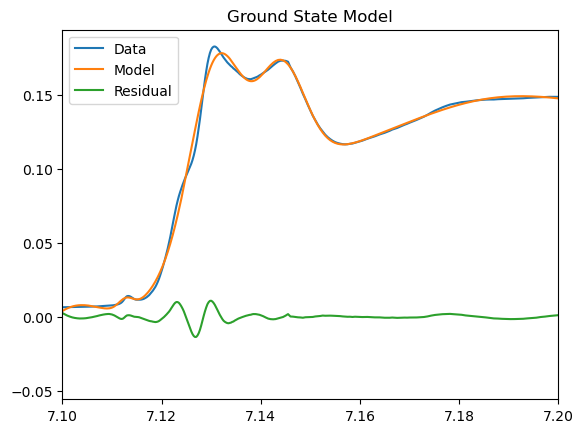

In [4]:
params0_gs = [7.125, .14, 0.003,
              .008, 7.113, .001,
              .025, 7.123, .0015,
              .06, 7.13, .004,
              .033, 7.145, .003,
              -.03, 7.16, .006,
              .005, 7.17, .015,
              .0075]

bounds_gs = [(7.1, 7.2), (0, 1), (0, 1),
             (0.007, 0.03), (7.112, 7.114), (0.001, 0.0015),
             (0, 1), (7.1, 7.2), (0, 1),
             (0, 1), (7.1, 7.2), (0, 1),
             (0, 1), (7.1, 7.2), (0, 1),
             (-1, 1), (7.1, 7.2), (0, 1),
             (0, 1), (7.1, 7.2), (0, 1),
             (0, 1)]

result_gs = fit_static_xas(data['Energy'], data['OFF'], params0_gs, bounds_gs, fit_range=(7.1, 7.62))
params_opt = result_gs.x
print(params_opt)

y_mod = xas_model(data['Energy'], params_opt)

plt.figure()
plt.plot(data['Energy'], data['OFF'])
plt.plot(data['Energy'], y_mod)
plt.plot(data['Energy'], data['OFF'] - y_mod)
plt.legend(['Data', 'Model', 'Residual'])
plt.title('Ground State Model')
plt.xlim(7.1, 7.2)

Text(0.5, 1.0, 'Ground State Model Components')

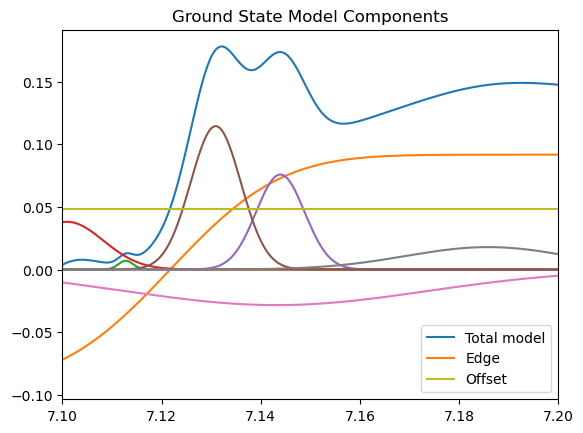

In [5]:
# Plot the individual components of the ground-state model
plt.figure()
plt.plot(data['Energy'], y_mod, label='Total model')
plt.plot(data['Energy'], erf_step(data['Energy'], params_opt[0], params_opt[1], params_opt[2]), label='Edge')
for i in range(3, len(params_opt) - 1, 3):
    plt.plot(data['Energy'], params_opt[i] * gaussian(data['Energy'], params_opt[i + 1], params_opt[i + 2]))
plt.plot(data['Energy'], np.zeros_like(data['Energy']) + params_opt[-1], label='Offset')
plt.xlim(7.1, 7.2)
plt.legend()
plt.title('Ground State Model Components')

### Fit Excited State

[ 7.12854843e+00  6.67684284e-02  1.45868870e-03  7.00000000e-03
  7.11237054e+00  1.06695313e-03  7.00000000e-03  7.11536870e+00
  1.00000000e-03  5.24268058e-02  7.14962075e+00  9.24076318e-03
  1.57046285e-01  7.12595761e+00  3.65554414e-03  3.12934003e-02
  7.14373315e+00  0.00000000e+00 -8.93982650e-02  7.15215212e+00
  7.79170953e-03  1.61354261e-02  7.16357983e+00  1.35024666e-02
  7.32384235e-02]


(7.1, 7.2)

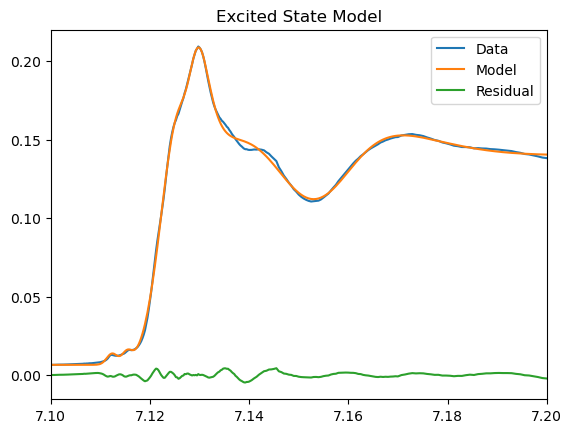

In [6]:
params0_es = [7.125, .14, 0.003,
              .008, 7.111, .001,
              .008, 7.117, .001,
              .025, 7.123, .0015,
              .06, 7.13, .004,
              .033, 7.145, .003,
              -.03, 7.16, .006,
              .005, 7.17, .015,
              .0075]

bounds_es = [(7.1, 7.2), (0, 1), (0, 1),
             (0.007, 0.03), (7.11, 7.114), (0.001, 0.0015),
             (0.007, 0.03), (7.115, 7.119), (0.001, 0.0015),
             (0, 1), (7.1, 7.2), (0, 1),
             (0, 1), (7.1, 7.2), (0, 1),
             (0, 1), (7.1, 7.2), (0, 1),
             (-1, 1), (7.1, 7.2), (0, 1),
             (0, 1), (7.1, 7.2), (0, 1),
             (0, 1)]

result_es = fit_static_xas(data['Energy'], data['ES'], params0_es, bounds_es, fit_range=(7.1, 7.62))
params_opt_es = result_es.x
print(params_opt_es)

y_mod_es = xas_model(data['Energy'], params_opt_es)

plt.figure()
plt.plot(data['Energy'], data['ES'])
plt.plot(data['Energy'], y_mod_es)
plt.plot(data['Energy'], data['ES'] - y_mod_es)
plt.legend(['Data', 'Model', 'Residual'])
plt.title('Excited State Model')
plt.xlim(7.1, 7.2)

Text(0.5, 1.0, 'Excited State Model Components')

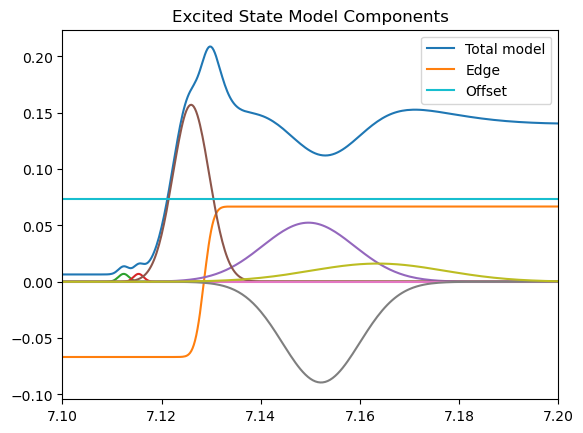

In [7]:
# Plot the individual components of the excited-state model
plt.figure()
plt.plot(data['Energy'], y_mod_es, label='Total model')
plt.plot(data['Energy'], erf_step(data['Energy'], params_opt_es[0], params_opt_es[1], params_opt_es[2]), label='Edge')
for i in range(3, len(params_opt_es) - 1, 3):
    plt.plot(data['Energy'], params_opt_es[i] * gaussian(data['Energy'], params_opt_es[i + 1], params_opt_es[i + 2]))
plt.plot(data['Energy'], np.zeros_like(data['Energy']) + params_opt_es[-1], label='Offset')
plt.xlim(7.1, 7.2)
plt.legend()
plt.title('Excited State Model Components')

### Save and Load the Fit Parameters

In [8]:
# Persist a fit with vio.save_fit_params, e.g.:
# vio.save_fit_params({'Ground State': params_opt, 'Excited State': params_opt_es}, 'FitResults_GS_ES.pkl')
# (the two rows may differ in length -- the shorter one is NaN-padded.)

# Reload the parameters bundled with this project. These were produced by the
# two fits above; re-run and re-save them if the model in xas_model.py changes,
# since the stored numbers carry no record of the edge convention they assume.
fit_params = vio.load_fit_params()
params_opt = fit_params.loc['Ground State'].dropna().values
params_opt_es = fit_params.loc['Excited State'].dropna().values
y_mod = xas_model(data['Energy'], params_opt)
y_mod_es = xas_model(data['Energy'], params_opt_es)

### Plot Model for Ground and Excited States

(7.1, 7.2)

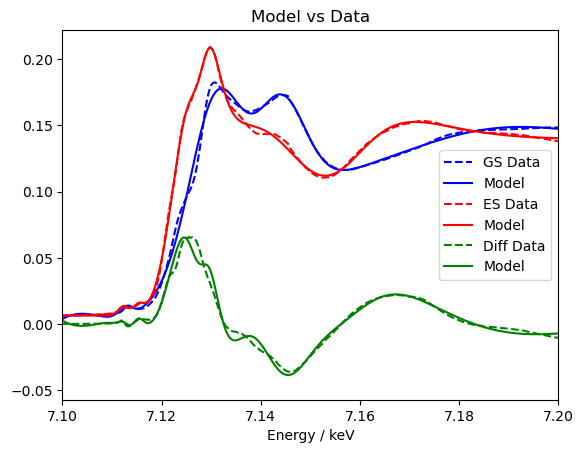

In [9]:
plt.figure()
plt.plot(data['Energy'], data['OFF'], '--', color='blue')
plt.plot(data['Energy'], y_mod, color='blue')
plt.plot(data['Energy'], data['ES'], '--', color='red')
plt.plot(data['Energy'], y_mod_es, color='red')
plt.plot(data['Energy'], data['Diff'] / 0.76, '--', color='green')
plt.plot(data['Energy'], y_mod_es - y_mod, color='green')
plt.legend(['GS Data', 'Model', 'ES Data', 'Model', 'Diff Data', 'Model'])
plt.title('Model vs Data')
plt.xlabel('Energy / keV')
plt.xlim(7.1, 7.2)

## Transient XAS Kinetics

The pump-probe delay scan measures a mixture of ground- and excited-state spectra, with the excited-state fraction rising and then decaying as described by an IRF-convolved population kinetics model -- see `docs/physics/03_ultrafast_pump_probe_kinetics.md`.

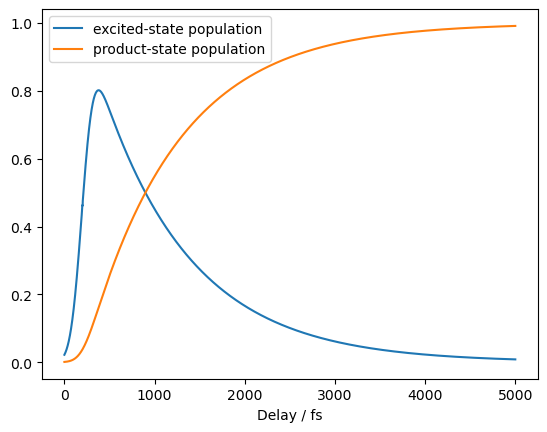

In [10]:
# Inspect the shape of the population-kinetics building blocks: population
# rising into the excited state and decaying (I1), vs. the complementary
# "downstream product" population (I2, not used further for this simple
# two-state ground/excited system, but shown for comparison with the XES
# notebook's three-state cascade).
delays_demo = np.arange(0, 5e3)
plt.figure()
plt.plot(delays_demo, excited_state_population(delays_demo, 200, 1, 100, 1000), label='excited-state population')
plt.plot(delays_demo, product_state_population(delays_demo, 200, 1, 100, 1000), label='product-state population')
plt.xlabel('Delay / fs')
plt.legend()

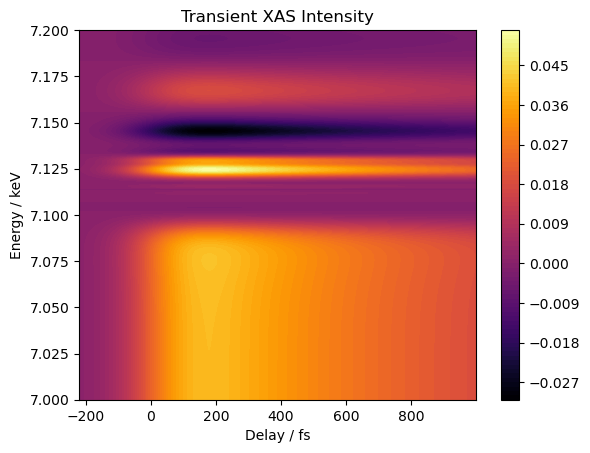

In [11]:
delays = np.arange(-220, 1e3, 1)
energy_array = np.arange(7., 7.2, 0.0001)

ground_state_spectrum = xas_model(energy_array, params_opt)
excited_state_spectrum = xas_model(energy_array, params_opt_es)

transient_map = build_transient_xas_map(
    ground_state_spectrum, excited_state_spectrum, delays,
    t0=0, i0=1, sigma=100, tau=1000,
)

plt.figure()
plt.contourf(delays, energy_array, transient_map, 100, cmap='inferno')
plt.title('Transient XAS Intensity')
plt.xlabel('Delay / fs')
plt.ylabel('Energy / keV')
plt.colorbar()

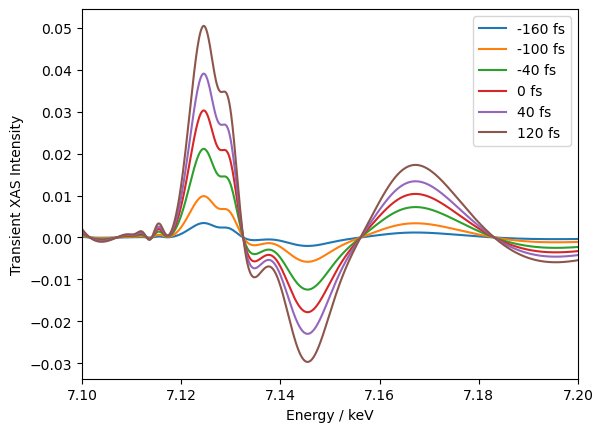

In [12]:
plt.figure()
for dp in [60, 120, 180, 220, 260, 340]:
    plt.plot(energy_array, transient_map[:, dp], label=f'{delays[dp]:.0f} fs')
plt.xlabel('Energy / keV')
plt.xlim([7.1, 7.2])
plt.ylabel('Transient XAS Intensity')
plt.legend()